# FEATURE / PREPROCESSING 

In [1]:
from pathlib import Path 
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np, scipy, sklearn
np.__version__, scipy.__version__, sklearn.__version__

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


('1.26.4', '1.11.4', '1.4.2')

In [2]:
DB_DIR = Path("../database")
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]

In [3]:
print("DB_DIR:", DB_DIR)
print("exists:", DB_DIR.exists())
print("subdirs:", [p.name for p in DB_DIR.iterdir() if p.is_dir()])


DB_DIR: ../database
exists: True
subdirs: ['PNEUMONIA', 'NORMAL']


In [4]:
DB_DIR = Path("../database")
NORMAL_DIR = DB_DIR / "NORMAL"
PNEUMONIA_DIR = DB_DIR / "PNEUMONIA"

normal_files = sorted([p for p in NORMAL_DIR.rglob("*") if p.is_file()])
pneumonia_files = sorted([p for p in PNEUMONIA_DIR.rglob("*") if p.is_file()])

len(normal_files), len(pneumonia_files)

(234, 390)

# VISUALISATION 

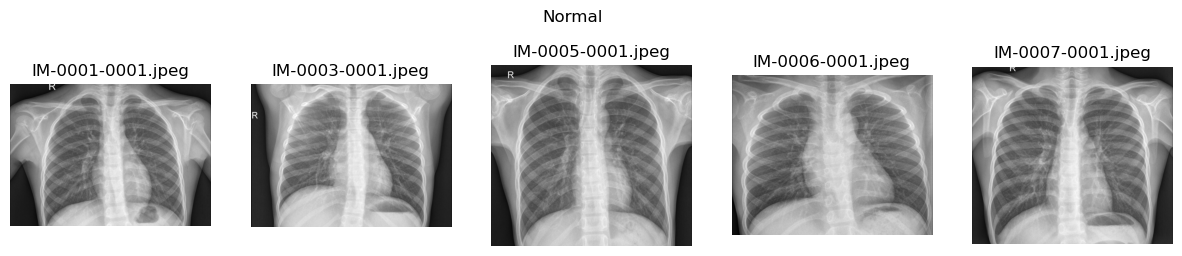

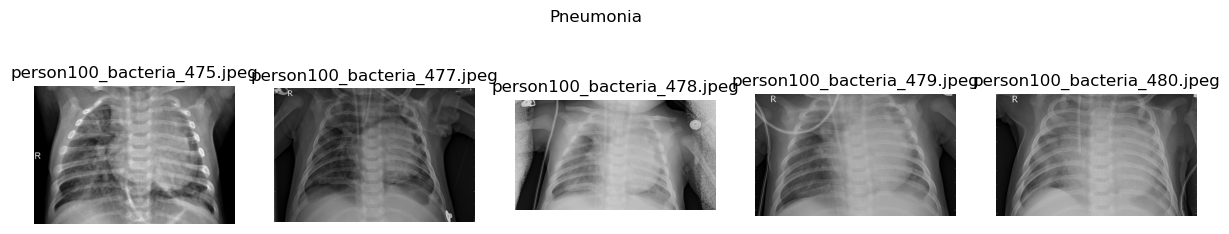

In [5]:
def show_images(files, title, n=5):
    plt.figure(figsize=(15, 3))
    for i, img_path in enumerate(files[:n]):
        img = Image.open(img_path).convert("L")
        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(img_path.name)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()
    
show_images(normal_files, "Normal")
show_images(pneumonia_files, "Pneumonia")

In [6]:
len(normal_files), len(pneumonia_files)

(234, 390)

In [7]:
X = normal_files + pneumonia_files
y = [0] * len(normal_files) + [1] * len(pneumonia_files)

len(X), len(y)

(624, 624)

In [ ]:
from sklearn.model_selection import train_test_split
SEED = 42

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_tmp
)

len(X_train), len(X_val), len(X_test)

NameError: name 'train_test_split' is not defined

# EXPLO DIMENSIONS IMAGES 

In [ ]:
def get_image_sizes(files, n=100):
    sizes = []
    for img_path in files[:n]:
        with Image.open(img_path) as img:
            sizes.append(img.size)
    return sizes

normal_sizes = get_image_sizes(normal_files)
pneumonia_sizes = get_image_sizes(pneumonia_files)

normal_sizes[:5], pneumonia_sizes[:5]


([(1857, 1317), (2111, 1509), (2031, 1837), (1663, 1326), (2053, 1818)],
 [(1106, 762), (1024, 680), (1128, 624), (904, 552), (880, 536)])

# RESUME STATISTIQUES DES TAILLES 

In [ ]:
def summarize_sizes(sizes):
    widths = [w for (w, h) in sizes]
    heights = [h for (w, h) in sizes]
    return {
        "count": len(sizes),
        "widths_min": min(widths),
        "widths_max": max(widths),
        "height_min": min(heights),
        "height_max": max(heights),
    }
    
summarize_sizes(normal_sizes), summarize_sizes(pneumonia_sizes)

({'count': 100,
  'widths_min': 1240,
  'widths_max': 2752,
  'height_min': 617,
  'height_max': 2713},
 {'count': 100,
  'widths_min': 832,
  'widths_max': 1496,
  'height_min': 496,
  'height_max': 1260})

# TRANSFORMS 

In [ ]:
from torchvision import transforms

IMAGE_SIZE = 224 

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])  

In [ ]:
train_transforms

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.5], std=[0.5])
)